## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [31]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [39]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [40]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

In [41]:
X = df.drop(columns=['math_score'],axis=1)

In [42]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [43]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [44]:
y = df['math_score']

In [45]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [46]:
# Select all numerical columns from X
# exclude="object" means:
# ignore text/categorical columns
# Example numerical columns:
# math_score, reading_score, writing_score
num_features = X.select_dtypes(exclude="object").columns


# Select all categorical/text columns from X
# include="object" means:
# take only string/text columns
# Example:
# gender, race_ethnicity, lunch
cat_features = X.select_dtypes(include="object").columns


# Import OneHotEncoder
# Used to convert categorical/text data into numerical format
# ML models cannot directly understand text values
# Example:
# male -> [1,0]
# female -> [0,1]
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Import ColumnTransformer
# Used to apply different preprocessing techniques
# on different columns simultaneously
from sklearn.compose import ColumnTransformer


# Create StandardScaler object
# StandardScaler scales numerical values
# so that:
# mean = 0
# standard deviation = 1
#
# Why scaling?
# Because features with large values can dominate ML models
#
# Example:
# Before scaling:
# age = 100
# salary = 100000
#
# After scaling:
# both become normalized
numeric_transformer = StandardScaler()


# Create OneHotEncoder object
# Converts categorical/text columns into binary vectors
#
# Example:
# gender:
# male   -> [1,0]
# female -> [0,1]
oh_transformer = OneHotEncoder()


# Create preprocessing pipeline using ColumnTransformer
# Applies:
# 1. OneHotEncoding to categorical columns
# 2. StandardScaling to numerical columns
preprocessor = ColumnTransformer(

    [
        # Apply OneHotEncoder on categorical features
        #
        # "OneHotEncoder" = name of transformation
        # oh_transformer = actual encoder object
        # cat_features = columns to apply encoding on
        ("OneHotEncoder", oh_transformer, cat_features),

        
        # Apply StandardScaler on numerical features
        #
        # "StandardScaler" = name of transformation
        # numeric_transformer = scaler object
        # num_features = numerical columns
        ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [47]:
# Fit the preprocessor on X and transform the data
# - Learns patterns like scaling values and encoding categories
# - Converts X into processed numerical format for ML models
X = preprocessor.fit_transform(X)

In [48]:
X.shape

(1000, 19)

In [49]:
X


array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [15]:
# Split data into training and testing sets
# 80% data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shape (rows, columns) of train and test data
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [16]:
# Function to evaluate model performance
def evaluate_model(true, predicted):
    
    # Mean Absolute Error
    mae = mean_absolute_error(true, predicted)
    
    # Mean Squared Error
    mse = mean_squared_error(true, predicted)
    
    # Root Mean Squared Error
    rmse = np.sqrt(mse)
    
    # R² Score (accuracy of prediction)
    r2_square = r2_score(true, predicted)

    # Return evaluation metrics
    return mae, rmse, r2_square

In [17]:
# Dictionary of different regression models
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

# Lists to store model names and R2 scores
model_list = []
r2_list = []

# Loop through each model
for i in range(len(list(models))):
    
    # Select model
    model = list(models.values())[i]
    
    # Train model using training data
    model.fit(X_train, y_train)

    # Predict on training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate training data performance
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_train_pred
    )

    # Evaluate testing data performance
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(
        y_test, y_test_pred
    )

    # Print model name
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    # Training results
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    # Testing results
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    # Store test R2 score
    r2_list.append(model_test_r2)

    print('=' * 35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3243
- Mean Absolute Error: 4.2671
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3960
- Mean Absolute Error: 4.2158
- R2 Score: 0.8803


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7077
- Mean Absolute Error: 4.5167
- R2 Score: 0.8555
-----------------------

In [ ]:
"""Model Performance Analysis
Best Performing Model
Ridge Regression
Test R² Score: 0.8806
Test RMSE: 5.3904
Test MAE: 4.2111

Ridge Regression performed the best among all models because:

Highest Test R² score
Lowest RMSE and MAE
Training and testing scores are very close → good generalization
No major overfitting



Comparison of Models
Model	Test R²	Observation
Ridge	0.8806	Best overall performance
Linear Regression	0.8803	Almost same as Ridge
Random Forest	0.8518	Good but slightly overfitting
CatBoost	0.8516	Good ensemble model
AdaBoost	0.8469	Decent performance
XGBoost	0.8278	Overfitting observed
Lasso	0.8253	Lower accuracy
KNN	0.7838	Weak generalization
Decision Tree	0.7758	Severe overfitting




Here’s a simple analysis of your regression model results:

---

# Model Performance Analysis

## Best Performing Model

### Ridge Regression

* **Test R² Score:** `0.8806`
* **Test RMSE:** `5.3904`
* **Test MAE:** `4.2111`

Ridge Regression performed the best among all models because:

* Highest Test R² score
* Lowest RMSE and MAE
* Training and testing scores are very close → good generalization
* No major overfitting

---

# Comparison of Models
 
| Model             | Test R² | Observation                   |
| ----------------- | ------- | ----------------------------- |
| Ridge             | 0.8806  | Best overall performance      |
| Linear Regression | 0.8803  | Almost same as Ridge          |
| Random Forest     | 0.8518  | Good but slightly overfitting |
| CatBoost          | 0.8516  | Good ensemble model           |
| AdaBoost          | 0.8469  | Decent performance            |
| XGBoost           | 0.8278  | Overfitting observed          |
| Lasso             | 0.8253  | Lower accuracy                |
| KNN               | 0.7838  | Weak generalization           |
| Decision Tree     | 0.7758  | Severe overfitting            |

---

# Important Observations

## 1. Linear Regression and Ridge performed best

Both models gave:

* High accuracy
* Stable predictions
* Low error values

This suggests:

* Dataset likely has a mostly linear relationship.
* Simpler models are working better than complex models.

---

## 2. Decision Tree is Overfitting

Decision Tree results:

* Train R² = `0.9997`
* Test R² = `0.7758`

This means:

* Model memorized training data
* Failed to generalize on unseen data

This is a classic case of **overfitting**.

---

## 3. Random Forest and CatBoost improved over Decision Tree

Ensemble methods reduced overfitting and improved test performance.

However:

* They still could not beat Ridge Regression.
* Complex models are not necessary for this dataset.

---

## 4. XGBoost also Overfit Slightly

* Training accuracy extremely high (`0.9955`)
* Test accuracy lower (`0.8278`)

Indicates slight overfitting.

---

# Final Conclusion

### Recommended Model: Ridge Regression

Why?

* Best Test R² score
* Lowest prediction error
* Stable and generalized well
* Simpler and computationally efficient

---

# Simple Interpretation of Metrics

## R² Score

Measures how well model explains data.

R^2 = 1 - \frac{SS_{res}}{SS_{tot}}

* Closer to `1` → Better model
* Your best model achieved around `0.88` → very good performance

---

## RMSE

Measures average prediction error.

RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}

Lower RMSE means better predictions.

---

## MAE

Average absolute error between actual and predicted values.

MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|

Lower MAE is better.


### Results

In [18]:
# Create DataFrame of model names and R2 scores
# Sort models based on highest R2 score
pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=['Model Name', 'R2_Score']
).sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880345
5,Random Forest Regressor,0.851817
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.846947
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.775827


In [ ]:
"""From the sorted R² scores:

Rank	Model	R² Score
1	Ridge	0.880593
2	Linear Regression	0.880345
3	Random Forest Regressor	0.851817
4	CatBoosting Regressor	0.851632
5	AdaBoost Regressor	0.846947


Key Insights
1. Ridge Regression performed best
Highest R² score
Very close train and test accuracy
Indicates strong generalization
Handles multicollinearity better than Linear Regression

This makes Ridge the most reliable model.

2. Linear Regression also performed extremely well

Difference between Ridge and Linear Regression is very small:

0.880593−0.880345≈0.000248

So both models are nearly identical in performance.


3. Ensemble models were good but not superior

Random Forest, CatBoost, and AdaBoost gave decent results, but:

More computationally expensive
Slightly lower R² score
More risk of overfitting

Hence simpler linear models are better here.




4. Decision Tree performed worst

Although training accuracy was almost perfect earlier, test accuracy dropped significantly.

This confirms:

Severe overfitting
Poor generalization ability

## Linear Regression

In [19]:
# Create Linear Regression model
lin_model = LinearRegression(fit_intercept=True)

# Train the model using training data
lin_model = lin_model.fit(X_train, y_train)

# Predict values for test data
y_pred = lin_model.predict(X_test)

# Calculate R2 score and convert to percentage
score = r2_score(y_test, y_pred) * 100

# Print model accuracy
print("Accuracy of the model is %.2f" % score)

Accuracy of the model is 88.03


## Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

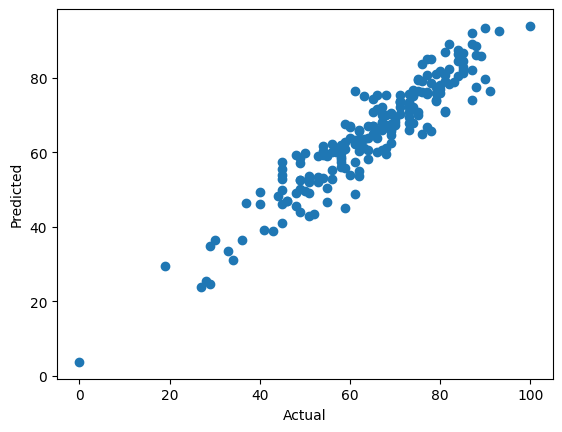

In [26]:
# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred)

# Label for x-axis
plt.xlabel('Actual')

# Label for y-axis
plt.ylabel('Predicted')

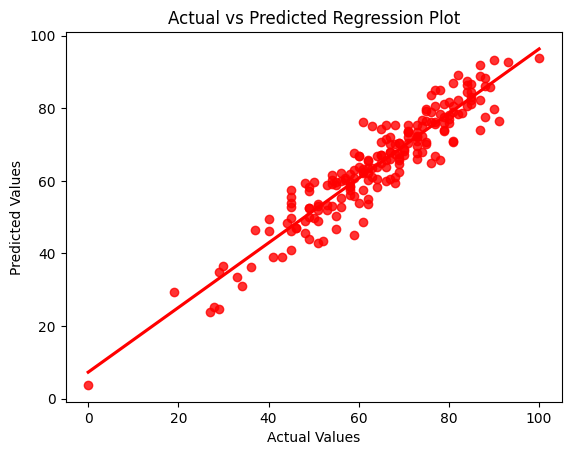

In [27]:
# Regression plot between actual and predicted values
sns.regplot(
    x=y_test,
    y=y_pred,
    ci=None,          # Removes confidence interval shading
    color='red'       # Line and scatter color
)

# Axis labels
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Title
plt.title('Actual vs Predicted Regression Plot')

# Show plot
plt.show()

#### Difference between Actual and Predicted Values

In [29]:
pred_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Error': abs(y_test - y_pred)
})

pred_df

,Actual Value,Predicted Value,Error
521,91,76.507812,14.492188
737,53,58.953125,5.953125
740,80,76.960938,3.039062
660,74,76.757812,2.757812
411,84,87.539062,3.539062
...,...,...,...
408,52,43.546875,8.453125
332,62,62.031250,0.031250
208,74,67.976562,6.023438
613,65,67.132812,2.132812


In [ ]:
Overall Observation

Most differences are small:

Around ±2 to ±6
Indicates good prediction performance

Very large differences are few, which is expected in real-world data.

In [30]:
# Average prediction error
avg_error = abs(y_test - y_pred).mean()

print("Average Error:", avg_error)

Average Error: 4.2158203125
